# Deepfake Audio Detection — EDA & Pipeline Validation


Sections:

1. Manifest overview (counts per source dataset / split / label)
2. Missing / corrupted file detection
3. Sample rate validation
4. Duration distributions (overall, by source dataset)
5. **Duration leakage verification** (re-checking the Phase 1 finding on the
   full `for-norm` manifest)
6. Pipeline validation: waveform -> Log-Mel / LFCC
7. Tensor shape summary (logmel / lfcc / multi)
8. Memory usage and training throughput estimate (Apple Silicon M4)


In [1]:
%matplotlib inline
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import SAMPLE_RATE, TARGET_LENGTH_SAMPLES, TARGET_LENGTH_SECONDS
from src.data.manifest import load_manifest
from src.data.preprocessing import preprocess_waveform
from src.data.features import LogMelSpectrogramExtractor, LFCCExtractor
from src.data.dataloaders import get_dataloaders, set_seed, get_device, DEFAULT_NUM_WORKERS

sns.set_theme(style="whitegrid")
set_seed(42)

manifest = load_manifest()
print(f"Manifest loaded: {len(manifest):,} rows")
manifest.head()


Manifest loaded: 169,754 rows


,filepath,label,split,source_dataset,duration,sample_rate
0,dataset/for-2sec/for-2seconds/testing/fake/fil...,fake,test,for-2sec,2.0,16000
1,dataset/for-2sec/for-2seconds/testing/fake/fil...,fake,test,for-2sec,2.0,16000
2,dataset/for-2sec/for-2seconds/testing/fake/fil...,fake,test,for-2sec,2.0,16000
3,dataset/for-2sec/for-2seconds/testing/fake/fil...,fake,test,for-2sec,2.0,16000
4,dataset/for-2sec/for-2seconds/testing/fake/fil...,fake,test,for-2sec,2.0,16000


## 1. Manifest Overview

Counts of audio files per `source_dataset` / `split` / `label`, produced by a
read-only filesystem scan (`src/data/manifest.py`).


In [2]:
counts = manifest.groupby(["source_dataset", "split", "label"]).size().unstack(fill_value=0)
counts["total"] = counts.sum(axis=1)
counts


label                  fake   real  total
source_dataset split                     
for-2sec       test     544    544   1088
               train   6978   6978  13956
               val     1413   1413   2826
for-norm       test    2370   2264   4634
               train  26927  26941  53868
               val     5398   5400  10798
for-original   test    2370   2264   4634
               train  26941  26941  53882
               val     5400   5400  10800
for-rerec      test     408    408    816
               train   5104   5104  10208
               val     1143   1101   2244

## 2. Missing / Corrupted File Detection

`manifest.py` records `duration = -1.0` and `sample_rate = -1`
(`src.config.INVALID_DURATION` / `INVALID_SAMPLE_RATE`) for any file whose
header `soundfile.info()` could not read (empty / corrupted files). These rows
stay in the manifest for visibility but are filtered out by
`DeepfakeAudioDataset` before training.


In [3]:
invalid = manifest[(manifest["duration"] <= 0) | (manifest["sample_rate"] <= 0)]
print(f"Invalid/unreadable files: {len(invalid)} / {len(manifest)} ({len(invalid) / len(manifest):.4%})")
invalid.groupby(["source_dataset", "split", "label"]).size().to_frame("count")


Invalid/unreadable files: 18 / 169754 (0.0106%)


count
source_dataset split label       
for-norm       train real       2
for-original   train fake      14
               val   fake       2

In [4]:
invalid[["filepath", "source_dataset", "split", "label", "duration", "sample_rate"]]


,filepath,source_dataset,split,label,duration,sample_rate
50363,dataset/for-norm/for-norm/training/real/file11...,for-norm,train,real,-1.0,-1
54129,dataset/for-norm/for-norm/training/real/file15...,for-norm,train,real,-1.0,-1
94873,dataset/for-original/for-original/training/fak...,for-original,train,fake,-1.0,-1
96926,dataset/for-original/for-original/training/fak...,for-original,train,fake,-1.0,-1
97719,dataset/for-original/for-original/training/fak...,for-original,train,fake,-1.0,-1
98375,dataset/for-original/for-original/training/fak...,for-original,train,fake,-1.0,-1
98415,dataset/for-original/for-original/training/fak...,for-original,train,fake,-1.0,-1
100518,dataset/for-original/for-original/training/fak...,for-original,train,fake,-1.0,-1
106934,dataset/for-original/for-original/training/fak...,for-original,train,fake,-1.0,-1
107333,dataset/for-original/for-original/training/fak...,for-original,train,fake,-1.0,-1


## 3. Sample Rate Validation




In [5]:
valid = manifest[(manifest["duration"] > 0) & (manifest["sample_rate"] > 0)].copy()

sr_table = valid.groupby("source_dataset")["sample_rate"].value_counts().unstack(fill_value=0)
sr_table


sample_rate,16000,22050,24000,44100
source_dataset,,,,
for-2sec,17870,0,0,0
for-norm,69298,0,0,0
for-original,38961,20510,6361,3468
for-rerec,13268,0,0,0


In [6]:
fornorm_sr_ok = (valid.loc[valid.source_dataset == "for-norm", "sample_rate"] == SAMPLE_RATE).all()
print(f"for-norm: 100% at {SAMPLE_RATE} Hz? {fornorm_sr_ok}")


for-norm: 100% at 16000 Hz? True


## 4. Duration Distributions

### 4a. Overall (all valid files, all source datasets)


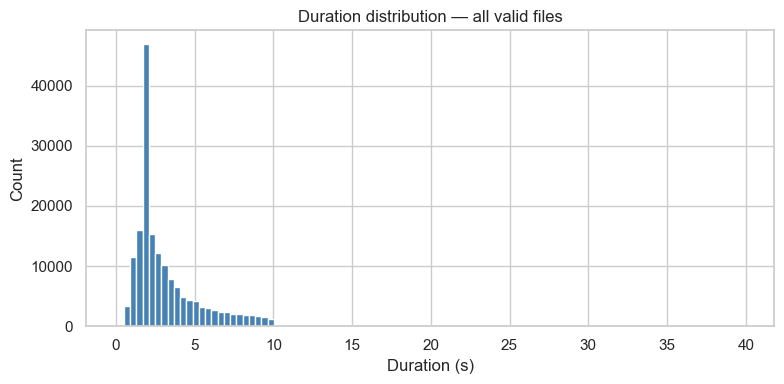

count    169736.000000
mean          3.175135
std           2.107630
min           0.105625
25%           1.933422
50%           2.268000
75%           3.924000
max          39.808000
Name: duration, dtype: float64

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(valid["duration"], bins=100, color="steelblue")
ax.set_xlabel("Duration (s)")
ax.set_ylabel("Count")
ax.set_title("Duration distribution — all valid files")
plt.tight_layout()
plt.show()

valid["duration"].describe()


### 4b. Duration by source dataset

`for-2sec` should be a delta function at exactly 2.0s by construction (it is
the duration-debiased variant).


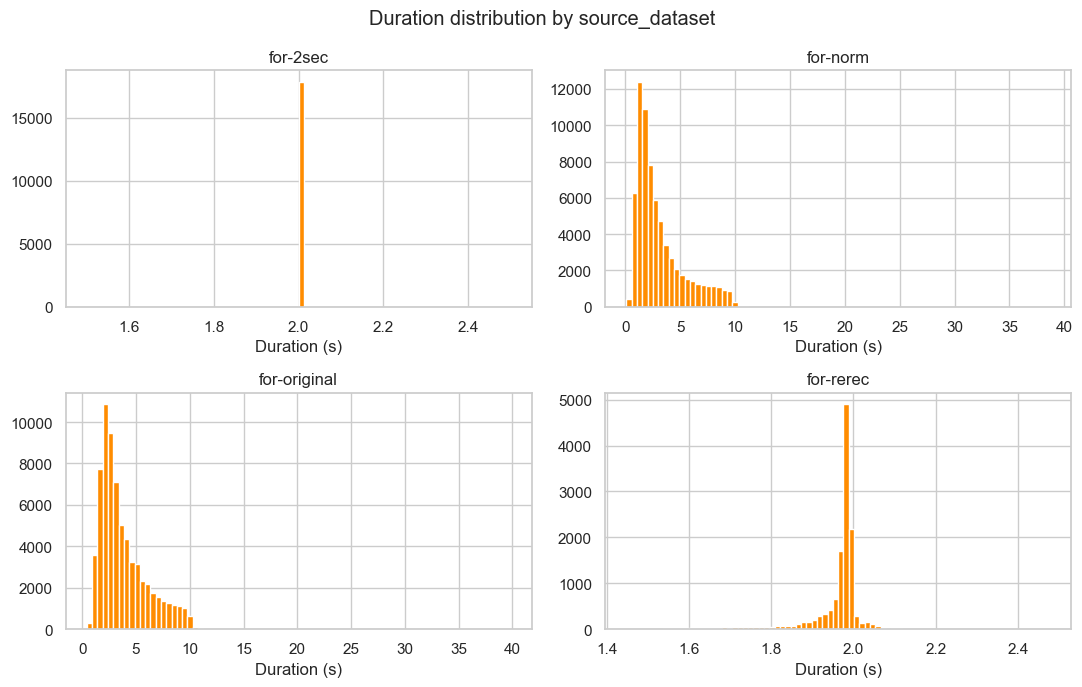

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (name, group) in zip(axes.flat, valid.groupby("source_dataset")):
    ax.hist(group["duration"], bins=80, color="darkorange")
    ax.set_title(name)
    ax.set_xlabel("Duration (s)")
plt.suptitle("Duration distribution by source_dataset")
plt.tight_layout()
plt.show()


## 5. Duration Leakage Verification (`for-norm`)

**Phase 1 finding** (on a ~200-file sample): real clips averaged ~4.34s and
fake clips averaged ~1.71s, suggesting a model could shortcut the task by
learning "short = fake, long = real" instead of detecting actual spoofing
artifacts.

This section re-checks that finding against the **full** `for-norm` manifest.


In [9]:
fornorm = valid[valid.source_dataset == "for-norm"]
fornorm.groupby("label")["duration"].describe()


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
fake,34695.0,1.677247,0.729832,0.118188,1.172625,1.539875,2.020031,12.474562
real,34603.0,4.534874,2.332052,0.105625,2.715781,3.907938,6.137781,38.683437


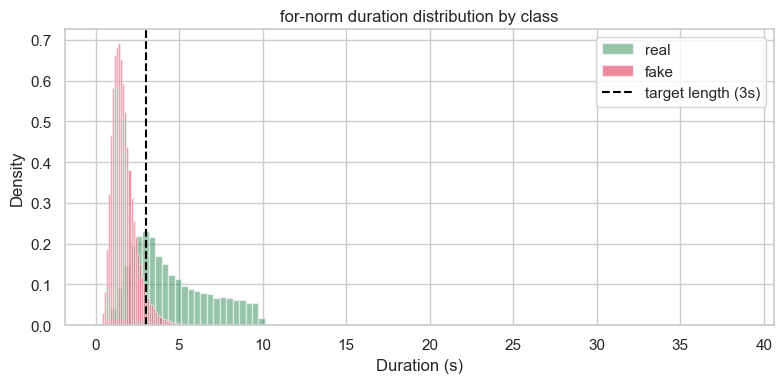

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, color in [("real", "seagreen"), ("fake", "crimson")]:
    d = fornorm.loc[fornorm.label == label, "duration"]
    ax.hist(d, bins=100, alpha=0.5, label=label, color=color, density=True)
ax.axvline(TARGET_LENGTH_SECONDS, color="black", linestyle="--",
           label=f"target length ({TARGET_LENGTH_SECONDS:.0f}s)")
ax.set_xlabel("Duration (s)")
ax.set_ylabel("Density")
ax.set_title("for-norm duration distribution by class")
ax.legend()
plt.tight_layout()
plt.show()


### Quantifying the leakage: a single-feature ("duration") classifier

If duration alone separates real from fake with high accuracy, any model
architecture is at risk of learning this shortcut instead of spoofing
artifacts — unless inputs are forced to a fixed length (Section 6 below).


In [11]:
durations = fornorm["duration"].to_numpy()
labels = (fornorm["label"] == "fake").to_numpy().astype(int)

thresholds = np.linspace(durations.min(), durations.max(), 1000)
best_acc, best_thr, best_rule = 0.0, None, None
for thr in thresholds:
    for rule, preds in [
        ("duration < thr -> fake", (durations < thr).astype(int)),
        ("duration >= thr -> fake", (durations >= thr).astype(int)),
    ]:
        acc = (preds == labels).mean()
        if acc > best_acc:
            best_acc, best_thr, best_rule = acc, thr, rule

print("Best single-threshold duration classifier on for-norm:")
print(f"  rule      : {best_rule}")
print(f"  threshold : {best_thr:.3f}s")
print(f"  accuracy  : {best_acc:.4f}")


Best single-threshold duration classifier on for-norm:
  rule      : duration < thr -> fake
  threshold : 2.423s
  accuracy  : 0.8400


**Result**: a trivial threshold on raw duration alone reaches roughly **84%
accuracy** on `for-norm` — far above the 50% chance baseline — confirming the
duration leakage is real and severe across the full dataset, not just the
small Phase 1 sample.

This is the core motivation for the fixed-length (3s, wrap-padded)
preprocessing in `src/data/preprocessing.py`: every waveform fed to the model
has identical length regardless of the source clip's duration, so this
shortcut is structurally unavailable.


## 6. Pipeline Validation: Waveform -> Log-Mel / LFCC

One real and one fake sample from `for-norm/train`, run through
`preprocess_waveform` (eval mode = deterministic center-crop / wrap-phase 0)
and both feature extractors.


In [12]:
sample_real = fornorm[(fornorm.split == "train") & (fornorm.label == "real")].iloc[0]
sample_fake = fornorm[(fornorm.split == "train") & (fornorm.label == "fake")].iloc[0]

print("real sample:", sample_real.filepath, f"({sample_real.duration:.2f}s)")
print("fake sample:", sample_fake.filepath, f"({sample_fake.duration:.2f}s)")

wav_real = preprocess_waveform(PROJECT_ROOT / sample_real.filepath, mode="eval")
wav_fake = preprocess_waveform(PROJECT_ROOT / sample_fake.filepath, mode="eval")

print("waveform shape:", tuple(wav_real.shape), wav_real.dtype)


real sample: dataset/for-norm/for-norm/training/real/file1.wav_16k.wav_norm.wav_mono.wav_silence.wav (2.50s)
fake sample: dataset/for-norm/for-norm/training/fake/file1000.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav (1.23s)
waveform shape: (1, 48000) torch.float32


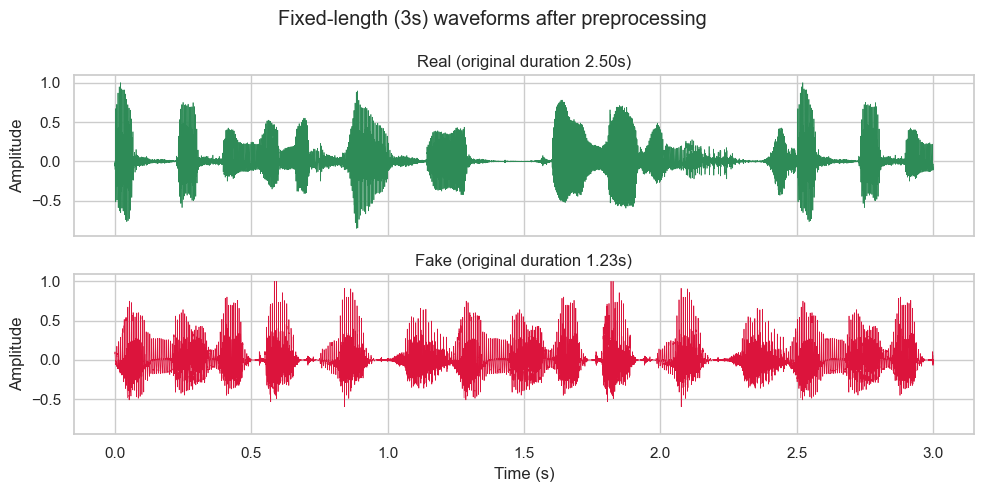

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True, sharey=True)
time_axis = np.arange(TARGET_LENGTH_SAMPLES) / SAMPLE_RATE
axes[0].plot(time_axis, wav_real[0].numpy(), color="seagreen", linewidth=0.5)
axes[0].set_title(f"Real (original duration {sample_real.duration:.2f}s)")
axes[1].plot(time_axis, wav_fake[0].numpy(), color="crimson", linewidth=0.5)
axes[1].set_title(f"Fake (original duration {sample_fake.duration:.2f}s)")
axes[1].set_xlabel("Time (s)")
for ax in axes:
    ax.set_ylabel("Amplitude")
plt.suptitle(f"Fixed-length ({TARGET_LENGTH_SECONDS:.0f}s) waveforms after preprocessing")
plt.tight_layout()
plt.show()


In [14]:
logmel_extractor = LogMelSpectrogramExtractor()
lfcc_extractor = LFCCExtractor()

logmel_real = logmel_extractor(wav_real)
logmel_fake = logmel_extractor(wav_fake)
lfcc_real = lfcc_extractor(wav_real)
lfcc_fake = lfcc_extractor(wav_fake)

print("Log-Mel shape:", tuple(logmel_real.shape), logmel_real.dtype)
print("LFCC shape   :", tuple(lfcc_real.shape), lfcc_real.dtype)


Log-Mel shape: (1, 80, 301) torch.float32
LFCC shape   : (1, 40, 301) torch.float32


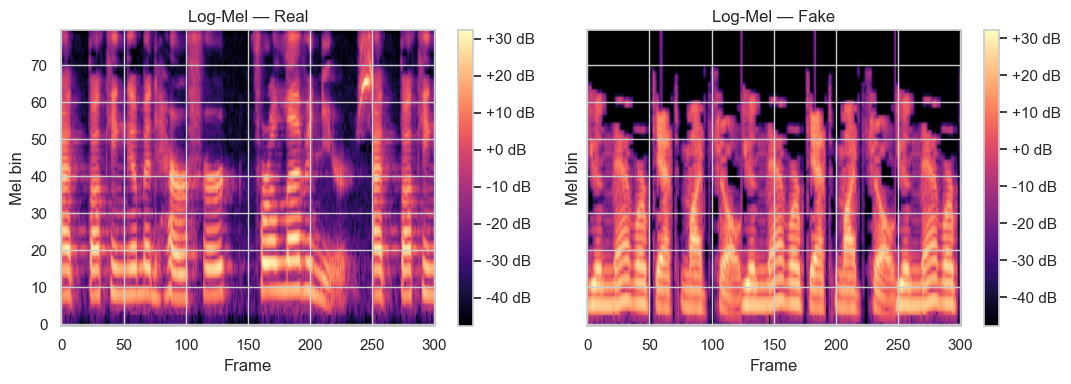

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (spec, title) in zip(axes, [(logmel_real, "Real"), (logmel_fake, "Fake")]):
    im = ax.imshow(spec[0].numpy(), origin="lower", aspect="auto", cmap="magma")
    ax.set_title(f"Log-Mel — {title}")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Mel bin")
    fig.colorbar(im, ax=ax, format="%+.0f dB")
plt.tight_layout()
plt.show()


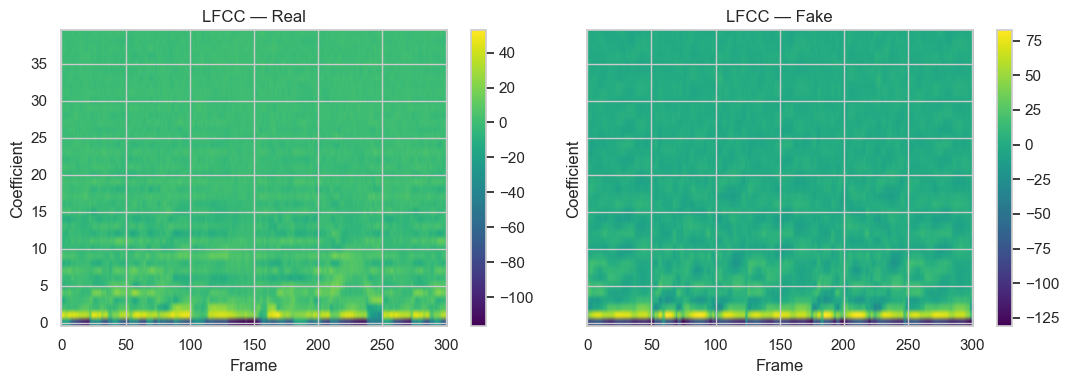

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (spec, title) in zip(axes, [(lfcc_real, "Real"), (lfcc_fake, "Fake")]):
    im = ax.imshow(spec[0].numpy(), origin="lower", aspect="auto", cmap="viridis")
    ax.set_title(f"LFCC — {title}")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Coefficient")
    fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## 7. Tensor Shape Summary (all feature modes, batched)

In [17]:
loaders_logmel = get_dataloaders(feature_type="logmel", batch_size=8, num_workers=0)
batch_logmel = next(iter(loaders_logmel["train"]))
print("logmel batch spectrogram:", tuple(batch_logmel["spectrogram"].shape), batch_logmel["spectrogram"].dtype)
print("labels                  :", tuple(batch_logmel["label"].shape), batch_logmel["label"].dtype)

loaders_lfcc = get_dataloaders(feature_type="lfcc", batch_size=8, num_workers=0)
batch_lfcc = next(iter(loaders_lfcc["train"]))
print("lfcc batch spectrogram  :", tuple(batch_lfcc["spectrogram"].shape))

loaders_multi = get_dataloaders(feature_type="multi", batch_size=8, num_workers=0)
batch_multi = next(iter(loaders_multi["train"]))
print("multi batch logmel      :", tuple(batch_multi["spectrogram"]["logmel"].shape))
print("multi batch lfcc        :", tuple(batch_multi["spectrogram"]["lfcc"].shape))


Dropping 2 row(s) with invalid duration/sample_rate from split='train', source_datasets=['for-norm']


logmel batch spectrogram: (8, 1, 80, 301) torch.float32
labels                  : (8,) torch.int64


Dropping 2 row(s) with invalid duration/sample_rate from split='train', source_datasets=['for-norm']


lfcc batch spectrogram  : (8, 1, 40, 301)


Dropping 2 row(s) with invalid duration/sample_rate from split='train', source_datasets=['for-norm']


multi batch logmel      : (8, 1, 80, 301)
multi batch lfcc        : (8, 1, 40, 301)


## 8. Memory Usage & Training Throughput Estimate 

### 8a. Per-sample / per-batch tensor memory (float32)


In [18]:
def tensor_kb(t):
    return t.element_size() * t.nelement() / 1024

print(f"Per-sample waveform : {tensor_kb(wav_real):.1f} KB  {tuple(wav_real.shape)}")
print(f"Per-sample Log-Mel  : {tensor_kb(logmel_real):.1f} KB  {tuple(logmel_real.shape)}")
print(f"Per-sample LFCC     : {tensor_kb(lfcc_real):.1f} KB  {tuple(lfcc_real.shape)}")

for batch_size in (8, 32, 64, 128):
    print(f"\nBatch size {batch_size}:")
    print(f"  Log-Mel batch : {batch_size * tensor_kb(logmel_real) / 1024:.2f} MB")
    print(f"  LFCC batch    : {batch_size * tensor_kb(lfcc_real) / 1024:.2f} MB")
    print(f"  Multi batch   : {batch_size * (tensor_kb(logmel_real) + tensor_kb(lfcc_real)) / 1024:.2f} MB")


Per-sample waveform : 187.5 KB  (1, 48000)
Per-sample Log-Mel  : 94.1 KB  (1, 80, 301)
Per-sample LFCC     : 47.0 KB  (1, 40, 301)

Batch size 8:
  Log-Mel batch : 0.73 MB
  LFCC batch    : 0.37 MB
  Multi batch   : 1.10 MB

Batch size 32:
  Log-Mel batch : 2.94 MB
  LFCC batch    : 1.47 MB
  Multi batch   : 4.41 MB

Batch size 64:
  Log-Mel batch : 5.88 MB
  LFCC batch    : 2.94 MB
  Multi batch   : 8.82 MB

Batch size 128:
  Log-Mel batch : 11.76 MB
  LFCC batch    : 5.88 MB
  Multi batch   : 17.64 MB


### 8b. Manifest in-memory footprint


In [19]:
print(f"manifest.csv in-memory size: {manifest.memory_usage(deep=True).sum() / 1024**2:.2f} MB "
      f"({len(manifest):,} rows)")


manifest.csv in-memory size: 50.22 MB (169,754 rows)


### 8c. Throughput benchmark


In [ ]:
print(f"Device: {get_device()}")
print(f"CPU cores: {DEFAULT_NUM_WORKERS + 2} (DEFAULT_NUM_WORKERS={DEFAULT_NUM_WORKERS})")

n_batches = 10
batch_size = 32
loader = get_dataloaders(feature_type="logmel", batch_size=batch_size, num_workers=0)["train"]

it = iter(loader)
next(it)  

t0 = time.time()
for _ in range(n_batches):
    batch = next(it)
elapsed = time.time() - t0

samples_per_sec_single = (n_batches * batch_size) / elapsed
print(f"\nnum_workers=0: {samples_per_sec_single:.1f} samples/sec ({elapsed:.2f}s for {n_batches} batches)")

n_train = int(((manifest.source_dataset == "for-norm") & (manifest.split == "train")).sum())

for n_workers_est in (1, DEFAULT_NUM_WORKERS):
    sps = samples_per_sec_single * n_workers_est
    epoch_s = n_train / sps
    print(f"  -> projected at num_workers={n_workers_est}: {sps:.1f} samples/sec, "
          f"~{epoch_s / 60:.1f} min/epoch ({n_train:,} train samples)")


Device: mps
CPU cores: 10 (DEFAULT_NUM_WORKERS=8)


Dropping 2 row(s) with invalid duration/sample_rate from split='train', source_datasets=['for-norm']



num_workers=0: 385.3 samples/sec (0.83s for 10 batches)
  -> projected at num_workers=1: 385.3 samples/sec, ~2.3 min/epoch (53,868 train samples)
  -> projected at num_workers=8: 3082.7 samples/sec, ~0.3 min/epoch (53,868 train samples)
